# EDA — Mid Lane Performance Analysis

**Focus**: death context, throw pattern detection, roaming timing.  
**Source**: `data/lol.duckdb` — 110 ranked Solo/Duo games.  
**Not included**: generic win-rate / KDA charts.

---

In [23]:
import sys
from pathlib import Path

# Make src/ importable from notebooks/
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

DB_PATH = PROJECT_ROOT / "data" / "lol.duckdb"
conn = duckdb.connect(str(DB_PATH), read_only=True)
print("Connected:", DB_PATH)

Connected: e:\PersonalProject\lol-ranked-analytics\data\lol.duckdb


In [24]:
# Dataset overview
overview = conn.execute("""
    SELECT
        (SELECT COUNT(*) FROM matches)           AS total_matches,
        (SELECT COUNT(*) FROM match_deaths)      AS total_deaths,
        (SELECT COUNT(*) FROM match_timelines)   AS total_timeline_rows,
        (SELECT COUNT(*) FROM match_timelines
         WHERE position_x IS NOT NULL)           AS rows_with_position,
        (SELECT COUNT(*) FROM matches
         WHERE opp_champion_name IS NOT NULL)    AS matches_with_opp_mid
""").df()
overview.T.rename(columns={0: "value"})

,value
total_matches,513
total_deaths,4124
total_timeline_rows,15273
rows_with_position,15273
matches_with_opp_mid,513


---
## 1 — Death Context Analysis

Each death is annotated with the player's relative gold position at that moment.  
Key questions:
- When in the game do most deaths occur?
- Are deaths happening while ahead (overextension) or behind (fighting from deficit)?
- How often do deaths cluster into tilt spirals (two deaths within 3 minutes)?

In [25]:
from src.features import death_context

dc = death_context(conn)

print(f"Total deaths: {len(dc)}")
print(f"Matches with ≥1 death: {dc['match_id'].nunique()}")
dc.head()

Total deaths: 3082
Matches with ≥1 death: 379


,match_id,death_number,timestamp_min,gold_at_death,gold_lead_approx,is_overextension_ahead,is_deficit_fight,is_early_death,is_tilt_spiral,is_post_laning_throw
0,VN2_1211406021,1,2,795,-16.097368,False,False,True,False,False
1,VN2_1211406021,2,5,1804,-36.788918,False,False,True,True,False
2,VN2_1211406021,3,7,3163,575.707124,True,False,False,True,False
3,VN2_1211406021,4,8,3574,618.619048,True,False,False,True,False
4,VN2_1211406021,5,11,4758,593.206349,True,False,False,True,False


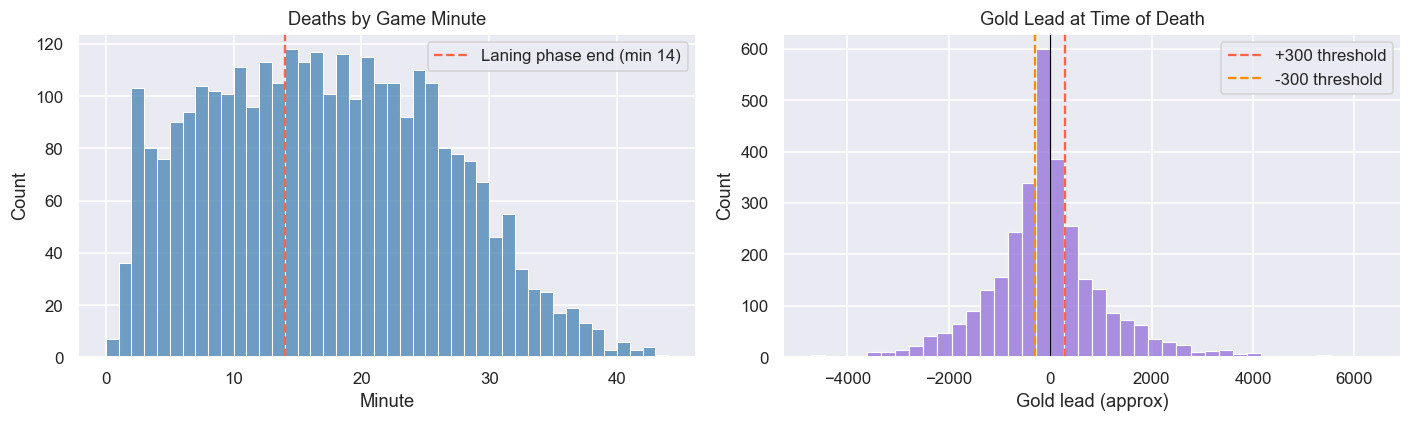

In [26]:
# Deaths per game minute
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(dc["timestamp_min"], bins=range(0, 45), ax=axes[0], color="steelblue")
axes[0].axvline(14, color="tomato", linestyle="--", label="Laning phase end (min 14)")
axes[0].set(title="Deaths by Game Minute", xlabel="Minute", ylabel="Count")
axes[0].legend()

# Gold lead at death — how rich/poor was the player when they died
sns.histplot(
    dc["gold_lead_approx"],
    bins=40,
    ax=axes[1],
    color="mediumpurple",
)
axes[1].axvline(0, color="black", linewidth=0.8, linestyle="-")
axes[1].axvline(300, color="tomato", linestyle="--", label="+300 threshold")
axes[1].axvline(-300, color="darkorange", linestyle="--", label="-300 threshold")
axes[1].set(title="Gold Lead at Time of Death", xlabel="Gold lead (approx)", ylabel="Count")
axes[1].legend()

plt.tight_layout()
plt.show()

In [27]:
# Death classification summary
bool_cols = [
    "is_overextension_ahead",
    "is_deficit_fight",
    "is_early_death",
    "is_tilt_spiral",
    "is_post_laning_throw",
]
summary = dc[bool_cols].sum().rename("death_count").to_frame()
summary["pct_of_deaths"] = (summary["death_count"] / len(dc) * 100).round(1)
print(summary.to_string())

                        death_count  pct_of_deaths
is_overextension_ahead          247            8.0
is_deficit_fight                343           11.1
is_early_death                  392           12.7
is_tilt_spiral                 1872           60.7
is_post_laning_throw            556           18.0


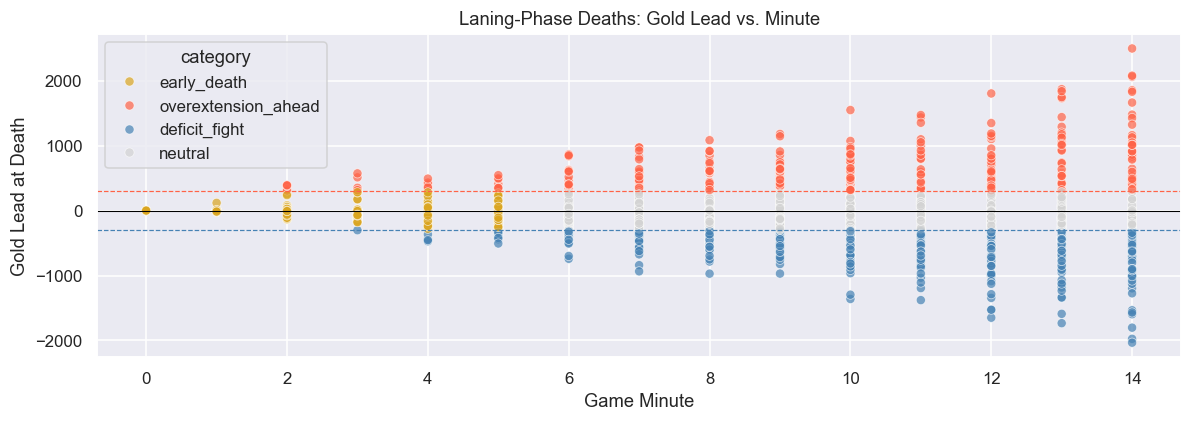

In [28]:
# Deaths coloured by category — laning phase only (min 0-14)
laning_dc = dc[dc["timestamp_min"] <= 14].copy()

def _label(row: pd.Series) -> str:
    if row["is_overextension_ahead"]:
        return "overextension_ahead"
    if row["is_deficit_fight"]:
        return "deficit_fight"
    if row["is_early_death"]:
        return "early_death"
    return "neutral"

laning_dc["category"] = laning_dc.apply(_label, axis=1)

palette = {
    "overextension_ahead": "tomato",
    "deficit_fight": "steelblue",
    "early_death": "goldenrod",
    "neutral": "lightgray",
}

fig, ax = plt.subplots(figsize=(11, 4))
sns.scatterplot(
    data=laning_dc,
    x="timestamp_min",
    y="gold_lead_approx",
    hue="category",
    palette=palette,
    alpha=0.7,
    ax=ax,
)
ax.axhline(0, color="black", linewidth=0.7)
ax.axhline(300, color="tomato", linestyle="--", linewidth=0.8)
ax.axhline(-300, color="steelblue", linestyle="--", linewidth=0.8)
ax.set(title="Laning-Phase Deaths: Gold Lead vs. Minute",
       xlabel="Game Minute", ylabel="Gold Lead at Death")
plt.tight_layout()
plt.show()

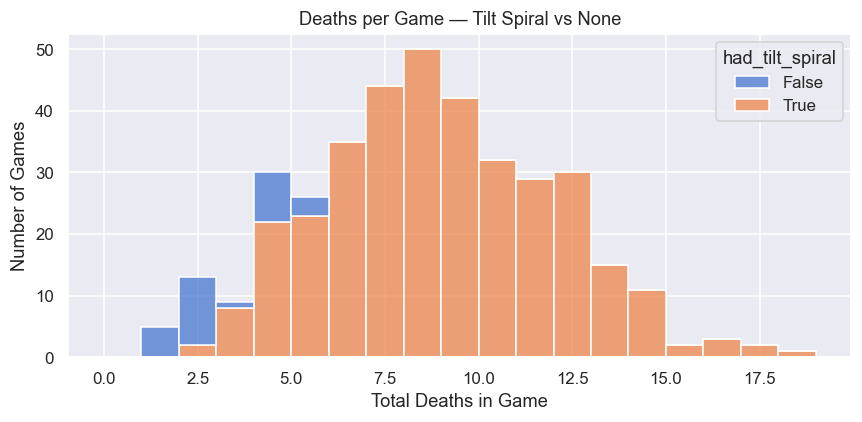

Games with tilt spiral: 351 / 379


In [29]:
# Tilt spiral: deaths per match coloured by whether any tilt spiral occurred
per_match = dc.groupby("match_id").agg(
    deaths=("death_number", "count"),
    tilt_spirals=("is_tilt_spiral", "sum"),
).reset_index()
per_match["had_tilt_spiral"] = per_match["tilt_spirals"] > 0

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(
    data=per_match,
    x="deaths",
    hue="had_tilt_spiral",
    bins=range(0, 20),
    multiple="stack",
    ax=ax,
)
ax.set(title="Deaths per Game — Tilt Spiral vs None",
       xlabel="Total Deaths in Game", ylabel="Number of Games")
plt.tight_layout()
plt.show()

print(f"Games with tilt spiral: {per_match['had_tilt_spiral'].sum()} / {len(per_match)}")

---
## 2 — Throw Pattern Detection

A **throw** game = player had ≥+300g gold lead at minute 14 but lost.  
A **comeback** game = player was ≥300g behind at minute 14 but won.  

Gold at minute 14 is the single best laning-phase outcome metric.

In [30]:
from src.features import is_throw_game

throw_df = is_throw_game(conn)

# Join win column from matches
win_df = conn.execute("SELECT match_id, win FROM matches").df()
throw_df = throw_df.merge(win_df, on="match_id", how="left")

print(f"Games with min-14 data: {len(throw_df)}")
print(f"Throw games  : {throw_df['is_throw'].sum()}")
print(f"Comeback games: {throw_df['is_comeback'].sum()}")
throw_df.head()

Games with min-14 data: 378
Throw games  : 48
Comeback games: 64


,match_id,gold_at_14,gold_delta,is_throw,is_comeback,win
0,VN2_1383796486,7254,1853.187831,False,False,True
1,VN2_1383845911,4813,-587.812169,False,True,True
2,VN2_1383912760,4323,-1077.812169,False,True,True
3,VN2_1384038707,5386,-14.812169,False,False,True
4,VN2_1384072523,5370,-30.812169,False,False,True


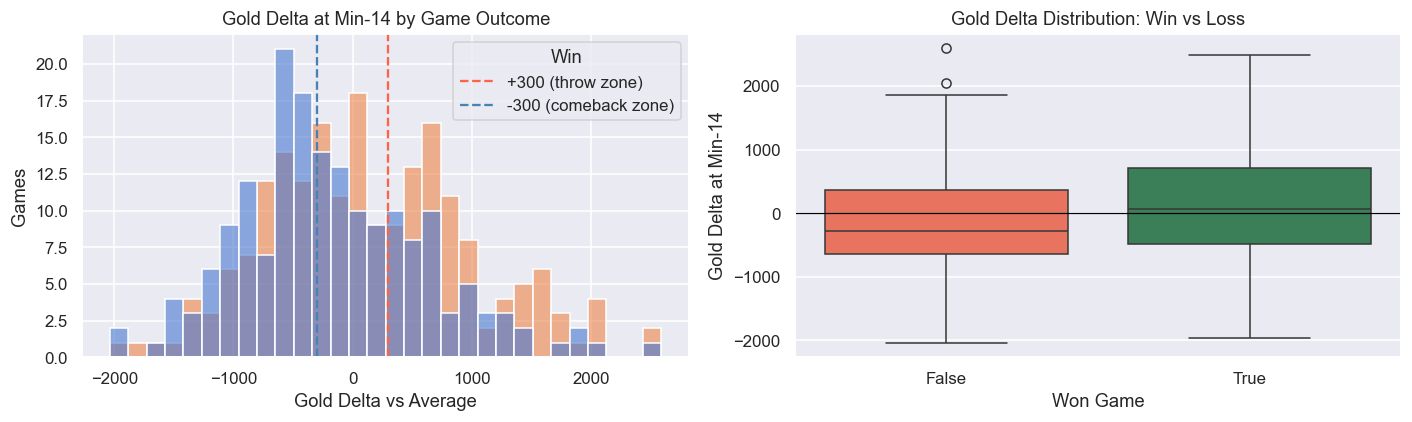

In [31]:
# Gold delta distribution — win vs loss
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(
    data=throw_df,
    x="gold_delta",
    hue="win",
    bins=30,
    ax=axes[0],
    multiple="layer",
    alpha=0.6,
)
axes[0].axvline(300, color="tomato", linestyle="--", label="+300 (throw zone)")
axes[0].axvline(-300, color="steelblue", linestyle="--", label="-300 (comeback zone)")
axes[0].set(title="Gold Delta at Min-14 by Game Outcome",
            xlabel="Gold Delta vs Average", ylabel="Games")
axes[0].legend(title="Win")

# Box plot: gold delta by outcome
sns.boxplot(
    data=throw_df,
    x="win",
    y="gold_delta",
    hue="win",
    palette={True: "seagreen", False: "tomato"},
    legend=False,
    ax=axes[1],
)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set(title="Gold Delta Distribution: Win vs Loss",
            xlabel="Won Game", ylabel="Gold Delta at Min-14")

plt.tight_layout()
plt.show()

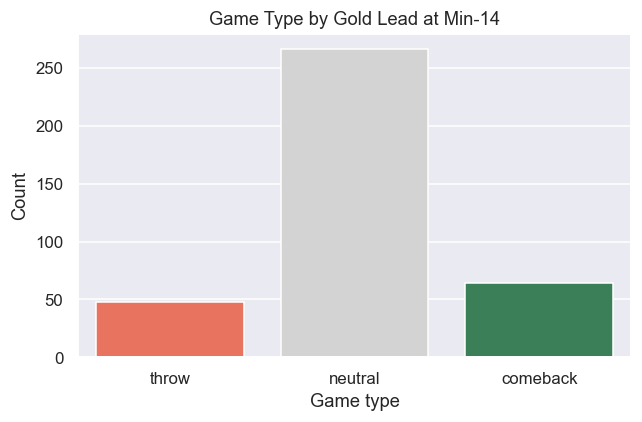

game_type
neutral     70.4
comeback    16.9
throw       12.7


In [32]:
# Throw / comeback / neutral breakdown
def _classify(row: pd.Series) -> str:
    if row["is_throw"]:
        return "throw"
    if row["is_comeback"]:
        return "comeback"
    return "neutral"

throw_df["game_type"] = throw_df.apply(_classify, axis=1)
counts = throw_df["game_type"].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
counts_df = pd.DataFrame({"game_type": counts.index, "count": counts.values})
sns.barplot(
    data=counts_df,
    x="game_type",
    y="count",
    hue="game_type",
    palette={"throw": "tomato", "comeback": "seagreen", "neutral": "lightgray"},
    order=["throw", "neutral", "comeback"],
    legend=False,
    ax=ax,
)
ax.set(title="Game Type by Gold Lead at Min-14",
       xlabel="Game type", ylabel="Count")
plt.tight_layout()
plt.show()

pct = (counts / counts.sum() * 100).round(1)
print(pct.to_string())

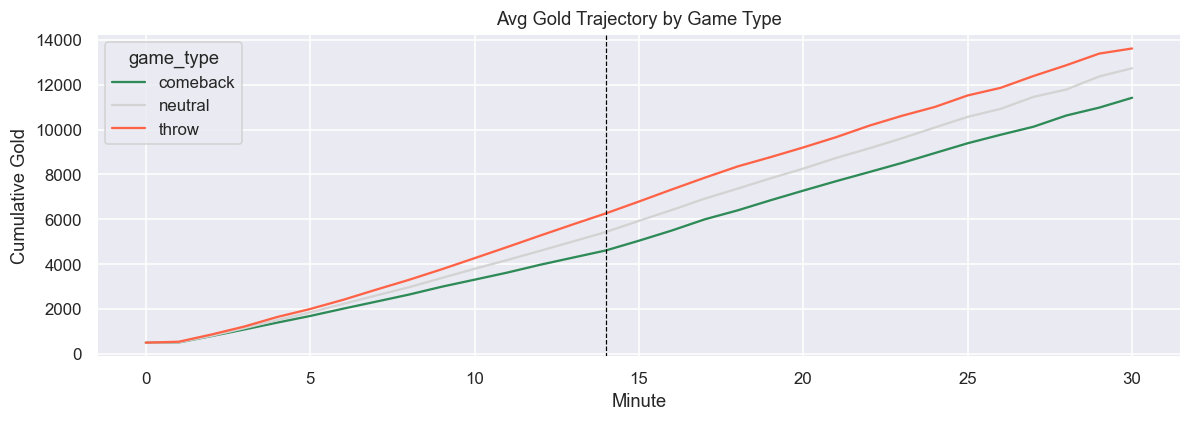

In [33]:
# Gold trajectory: average gold per minute for throw vs non-throw games
timeline_full = conn.execute("""
    SELECT match_id, timestamp_min, gold
    FROM match_timelines
    WHERE timestamp_min <= 30
    ORDER BY match_id, timestamp_min
""").df()

traj = timeline_full.merge(
    throw_df[["match_id", "game_type"]],
    on="match_id",
    how="left",
).dropna(subset=["game_type"])

traj_avg = traj.groupby(["game_type", "timestamp_min"])["gold"].mean().reset_index()

fig, ax = plt.subplots(figsize=(11, 4))
sns.lineplot(
    data=traj_avg,
    x="timestamp_min",
    y="gold",
    hue="game_type",
    palette={"throw": "tomato", "comeback": "seagreen", "neutral": "lightgray"},
    ax=ax,
)
ax.axvline(14, color="black", linestyle="--", linewidth=0.8, label="Min 14")
ax.set(title="Avg Gold Trajectory by Game Type",
       xlabel="Minute", ylabel="Cumulative Gold")
plt.tight_layout()
plt.show()

---
## 3 — Roaming Timing Analysis

Mid-lane roaming = leaving the mid corridor (abs(x - y) ≥ 2500 on the map grid)  
during minutes 4–14, for ≥ 2 consecutive minutes.

Key questions:
- How often does the player roam?
- What is the typical CS sacrifice?
- Does roaming convert to kills (impact) or not?

In [34]:
from src.features import roam_timing

roam_df = roam_timing(conn)

print(f"Total roam windows detected: {len(roam_df)}")
print(f"Matches with ≥1 roam: {roam_df['match_id'].nunique()}")
roam_df.head()

Total roam windows detected: 157
Matches with ≥1 roam: 123


,match_id,roam_start_min,roam_end_min,cs_before,cs_after,expected_cs_delta,cs_sacrifice,kills_during_roam,roam_result
0,VN2_1211406021,13,14,87,116,14.107719,0.000000,2,impact
1,VN2_1211445370,12,14,69,91,21.161578,0.000000,0,no_impact
2,VN2_1211467739,4,8,16,43,35.269297,8.269297,1,impact
3,VN2_1211467739,11,14,52,78,28.215437,2.215437,0,no_impact
4,VN2_1211488550,5,7,18,40,21.161578,0.000000,0,no_impact


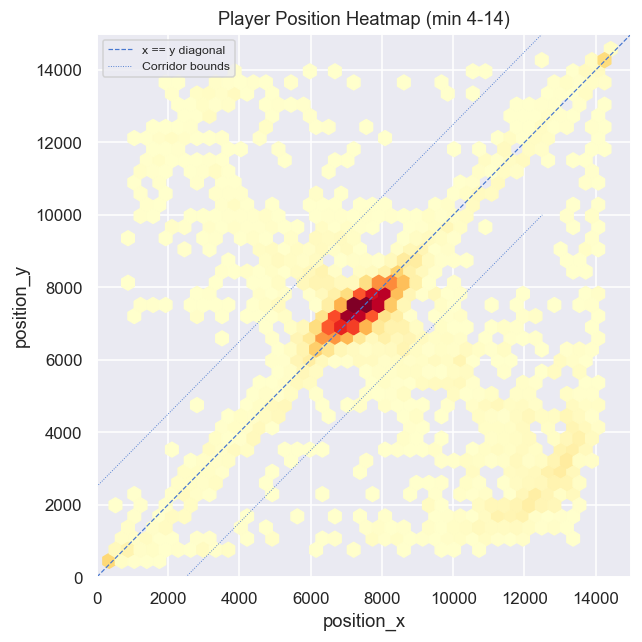

In [35]:
# Position heatmap for a sample of games — where does the player stand each minute?
pos_df = conn.execute("""
    SELECT match_id, timestamp_min, position_x, position_y
    FROM match_timelines
    WHERE timestamp_min BETWEEN 4 AND 14
      AND position_x IS NOT NULL
""").df()

fig, ax = plt.subplots(figsize=(6, 6))
ax.hexbin(
    pos_df["position_x"],
    pos_df["position_y"],
    gridsize=40,
    cmap="YlOrRd",
    mincnt=1,
)
# Mid-lane diagonal: x ≈ y
ax.plot([0, 15000], [0, 15000], "b--", linewidth=0.8, label="x == y diagonal")
ax.plot([0, 15000], [2500, 17500], "b:", linewidth=0.6)
ax.plot([0, 12500], [-2500, 10000], "b:", linewidth=0.6, label="Corridor bounds")
ax.set(title="Player Position Heatmap (min 4-14)",
       xlabel="position_x", ylabel="position_y",
       xlim=(0, 15000), ylim=(0, 15000))
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

C:\Users\PC\AppData\Local\Temp\ipykernel_26352\1399439060.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


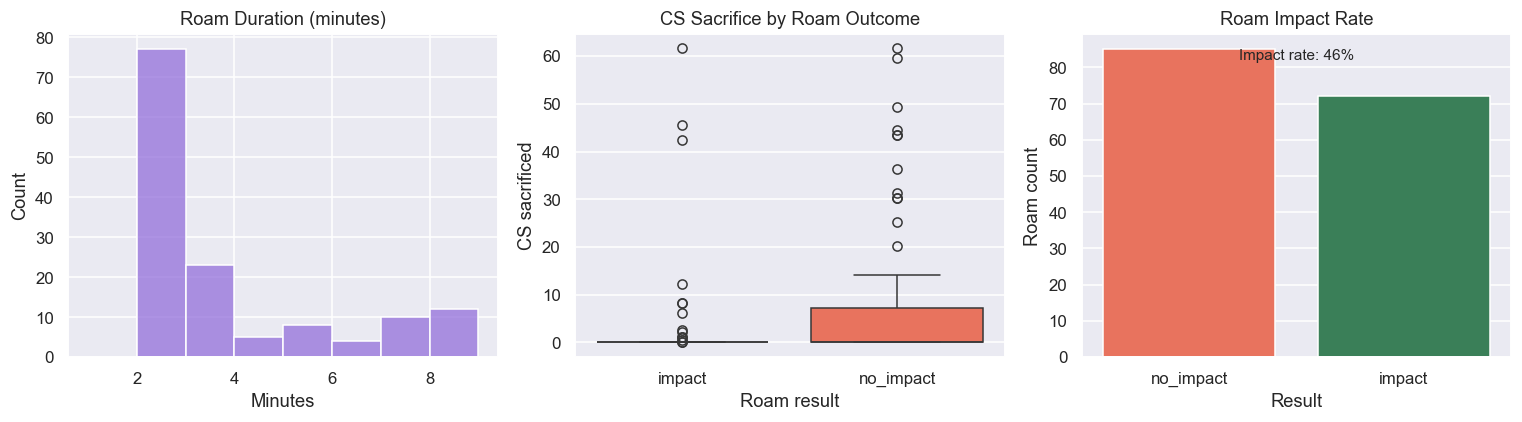

In [36]:
if not roam_df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    # Roam duration distribution
    roam_df["duration"] = roam_df["roam_end_min"] - roam_df["roam_start_min"] + 1
    sns.histplot(roam_df["duration"], bins=range(1, 10), ax=axes[0], color="mediumpurple")
    axes[0].set(title="Roam Duration (minutes)", xlabel="Minutes", ylabel="Count")

    # CS sacrifice by roam result
    sns.boxplot(
        data=roam_df,
        x="roam_result",
        y="cs_sacrifice",
        palette={"impact": "seagreen", "no_impact": "tomato"},
        ax=axes[1],
    )
    axes[1].set(title="CS Sacrifice by Roam Outcome",
                xlabel="Roam result", ylabel="CS sacrificed")

    # Impact rate bar
    impact_counts = roam_df["roam_result"].value_counts()
    ic_df = pd.DataFrame({"result": impact_counts.index, "count": impact_counts.values})
    sns.barplot(
        data=ic_df,
        x="result",
        y="count",
        hue="result",
        palette={"impact": "seagreen", "no_impact": "tomato"},
        legend=False,
        ax=axes[2],
    )
    axes[2].set(title="Roam Impact Rate", xlabel="Result", ylabel="Roam count")
    impact_rate = (impact_counts.get("impact", 0) / len(roam_df) * 100)
    axes[2].text(0.5, 0.92, f"Impact rate: {impact_rate:.0f}%",
                 transform=axes[2].transAxes, ha="center", fontsize=10)

    plt.tight_layout()
    plt.show()
else:
    print("No roam windows detected.")

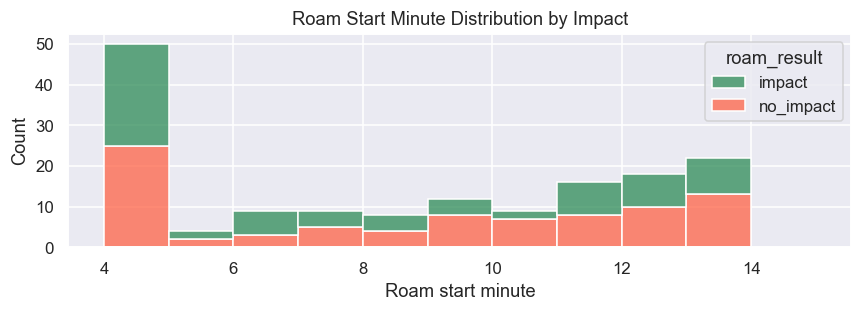

In [37]:
if not roam_df.empty:
    # Roam timing: when do roams start?
    fig, ax = plt.subplots(figsize=(8, 3))
    sns.histplot(
        data=roam_df,
        x="roam_start_min",
        hue="roam_result",
        bins=range(4, 16),
        multiple="stack",
        palette={"impact": "seagreen", "no_impact": "tomato"},
        ax=ax,
    )
    ax.set(title="Roam Start Minute Distribution by Impact",
           xlabel="Roam start minute", ylabel="Count")
    plt.tight_layout()
    plt.show()

---
## 4 — Champion Matchup Stats

In [38]:
from src.features import champion_matchup_stats

matchup_df = champion_matchup_stats(conn)

print(f"Matchups with ≥2 games: {len(matchup_df)}")
matchup_df.sort_values("games", ascending=False).head(10)

Matchups with ≥2 games: 61


,champion_name,opp_champion_name,games,our_avg_cs,opp_avg_cs,cs_diff,our_winrate,our_avg_kda,opp_avg_kda
55,Zoe,Sylas,8,194.125000,169.125000,25.000000,0.625000,2.960714,1.490774
49,Zoe,Katarina,6,176.000000,138.333333,37.666667,0.666667,2.892593,4.075463
60,Zoe,Zed,5,214.400000,233.600000,-19.200000,0.800000,1.326429,2.566667
56,Zoe,Syndra,5,227.800000,209.200000,18.600000,0.800000,2.633333,1.838095
38,Viktor,Ahri,4,226.500000,216.750000,9.750000,0.250000,1.033333,2.745833
53,Zoe,Malzahar,4,226.500000,241.000000,-14.500000,0.500000,1.878472,2.860119
36,Taliyah,Viktor,3,227.333333,204.333333,23.000000,0.666667,1.503788,14.222222
4,Ahri,TwistedFate,3,212.666667,194.000000,18.666667,1.000000,2.977778,2.388889
26,Orianna,Viktor,3,137.333333,126.333333,11.000000,0.666667,5.166667,2.716667
52,Zoe,Lux,3,204.666667,206.666667,-2.000000,0.666667,2.796296,3.607143


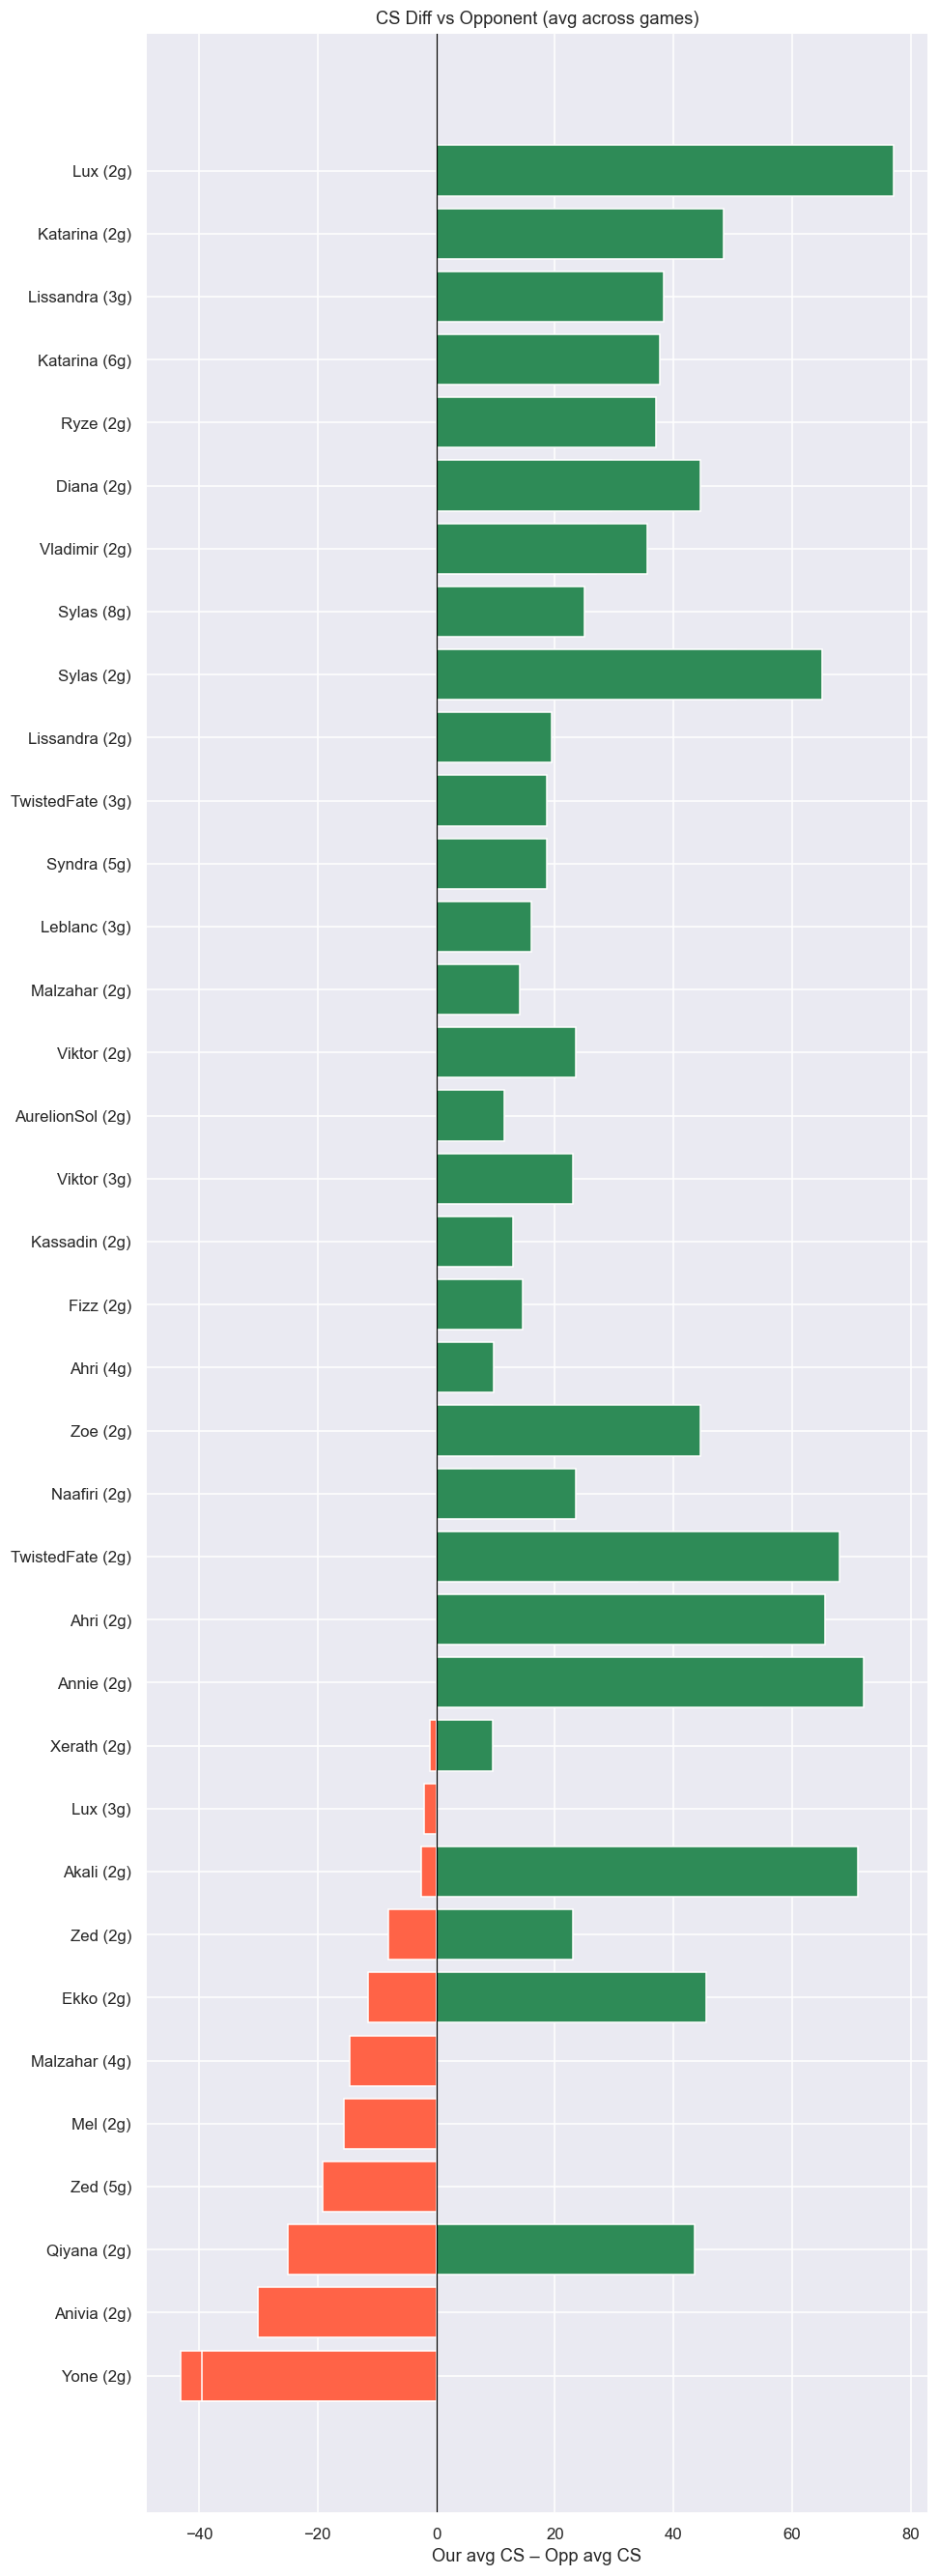

In [39]:
if not matchup_df.empty:
    fig, ax = plt.subplots(figsize=(9, max(3, len(matchup_df) * 0.4)))
    plot_data = matchup_df.sort_values("cs_diff")
    colors = ["seagreen" if v >= 0 else "tomato" for v in plot_data["cs_diff"]]
    ax.barh(
        plot_data["opp_champion_name"] + " (" + plot_data["games"].astype(str) + "g)",
        plot_data["cs_diff"],
        color=colors,
    )
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set(title="CS Diff vs Opponent (avg across games)",
           xlabel="Our avg CS – Opp avg CS")
    plt.tight_layout()
    plt.show()

---
## 5 — Tilt Index & Temporal Patterns

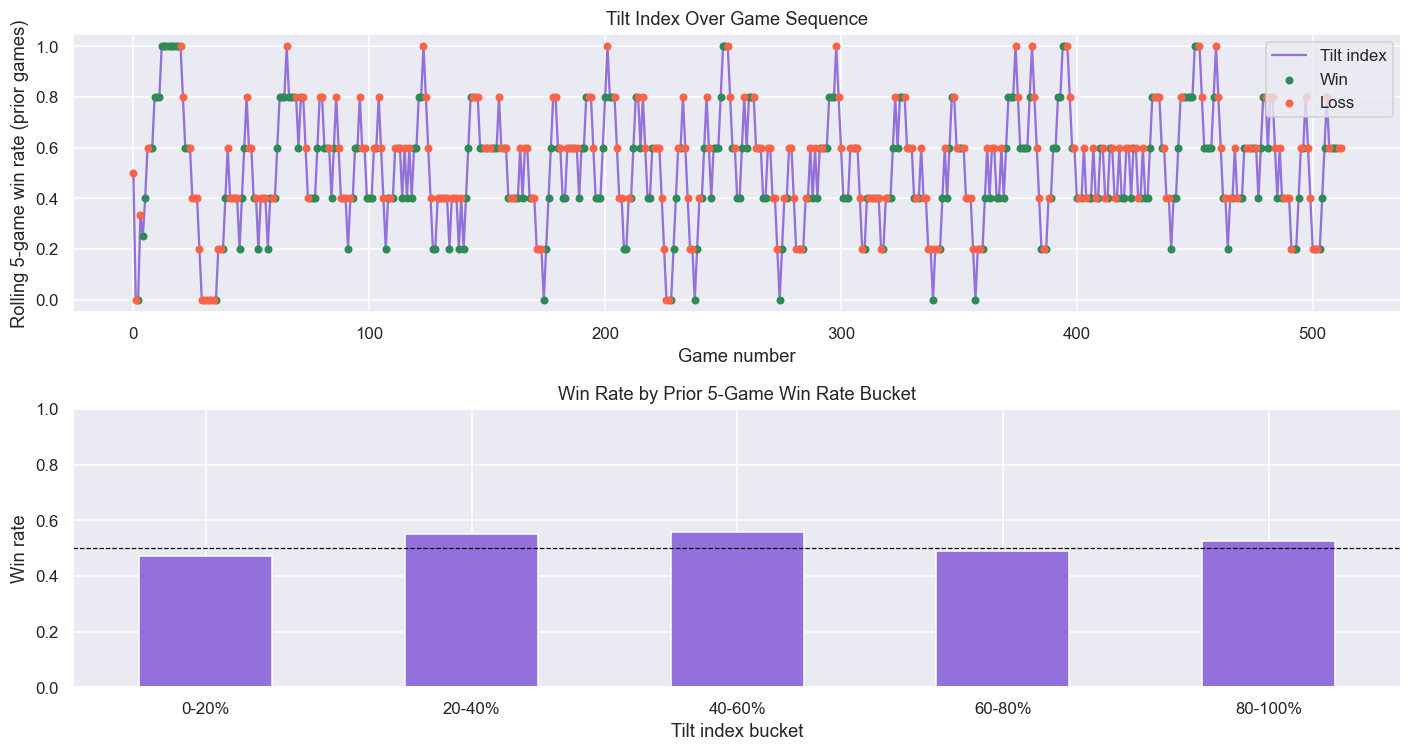

In [40]:
from src.features import tilt_index

tilt_df = tilt_index(conn)

tilt_df["game_datetime"] = pd.to_datetime(
    tilt_df["game_datetime"], format="ISO8601", utc=True
)
tilt_df = tilt_df.reset_index(drop=True)

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=False)

# Tilt index over time
axes[0].plot(tilt_df.index, tilt_df["tilt_index"], color="mediumpurple", label="Tilt index")
win_idx = tilt_df[tilt_df["win"]].index
loss_idx = tilt_df[~tilt_df["win"]].index
axes[0].scatter(win_idx, tilt_df.loc[win_idx, "tilt_index"],
                color="seagreen", s=18, zorder=3, label="Win")
axes[0].scatter(loss_idx, tilt_df.loc[loss_idx, "tilt_index"],
                color="tomato", s=18, zorder=3, label="Loss")
axes[0].set(title="Tilt Index Over Game Sequence",
            ylabel="Rolling 5-game win rate (prior games)",
            xlabel="Game number")
axes[0].legend()

# Win rate by tilt bucket
tilt_df["tilt_bucket"] = pd.cut(
    tilt_df["tilt_index"],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.01],
    labels=["0-20%", "20-40%", "40-60%", "60-80%", "80-100%"],
    right=False,
)
bucket_wr = tilt_df.groupby("tilt_bucket", observed=True)["win"].mean()
bucket_wr.plot(kind="bar", ax=axes[1], color="mediumpurple", rot=0)
axes[1].axhline(0.5, color="black", linestyle="--", linewidth=0.8)
axes[1].set(title="Win Rate by Prior 5-Game Win Rate Bucket",
            xlabel="Tilt index bucket", ylabel="Win rate")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

C:\Users\PC\AppData\Local\Temp\ipykernel_26352\3787020325.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


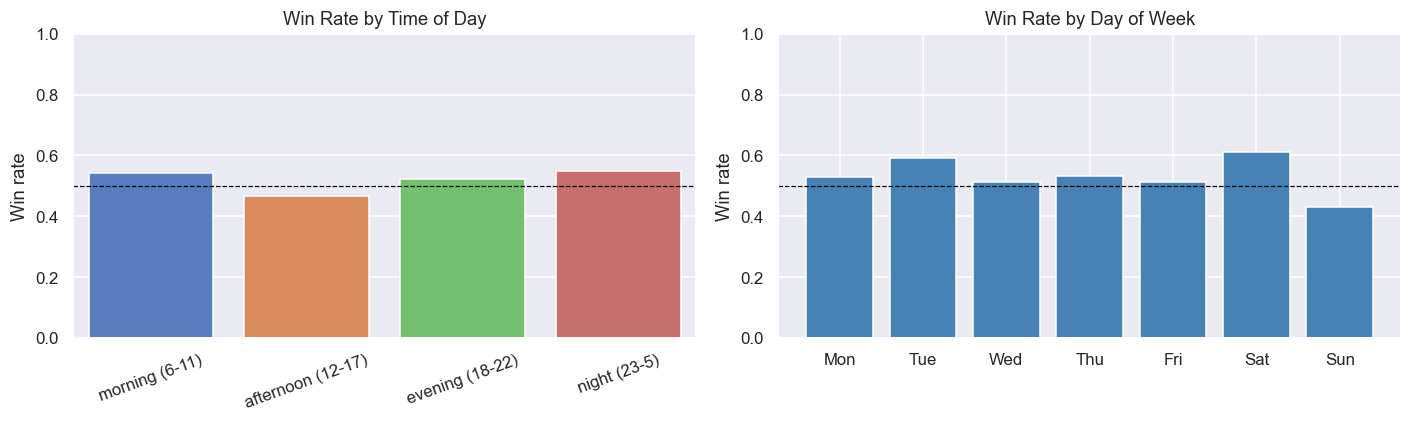

In [41]:
# Temporal: win rate by time bucket and day of week
matches_temporal = conn.execute("""
    SELECT match_id, game_datetime, win FROM matches ORDER BY game_datetime
""").df()
matches_temporal["game_datetime"] = pd.to_datetime(
    matches_temporal["game_datetime"], format="ISO8601", utc=True
)
# Convert to local time (UTC+7 for Vietnam)
matches_temporal["local_hour"] = (
    matches_temporal["game_datetime"] + pd.Timedelta(hours=7)
).dt.hour
matches_temporal["day_of_week"] = matches_temporal["game_datetime"].dt.dayofweek

def _tbucket(h: int) -> str:
    if 6 <= h <= 11: return "morning (6-11)"
    if 12 <= h <= 17: return "afternoon (12-17)"
    if 18 <= h <= 22: return "evening (18-22)"
    return "night (23-5)"

matches_temporal["time_bucket"] = matches_temporal["local_hour"].map(_tbucket)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

bucket_stats = (
    matches_temporal.groupby("time_bucket")["win"]
    .agg(win_rate="mean", games="count")
    .reset_index()
)
bucket_order = ["morning (6-11)", "afternoon (12-17)", "evening (18-22)", "night (23-5)"]
sns.barplot(
    data=bucket_stats,
    x="time_bucket",
    y="win_rate",
    order=bucket_order,
    palette="muted",
    ax=axes[0],
)
axes[0].axhline(0.5, color="black", linestyle="--", linewidth=0.8)
axes[0].set(title="Win Rate by Time of Day", xlabel="", ylabel="Win rate")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=20)

dow_stats = matches_temporal.groupby("day_of_week")["win"].mean()
dow_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
axes[1].bar(range(7), [dow_stats.get(i, float("nan")) for i in range(7)], color="steelblue")
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(dow_names)
axes[1].axhline(0.5, color="black", linestyle="--", linewidth=0.8)
axes[1].set(title="Win Rate by Day of Week", ylabel="Win rate")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()


---
## 6 — Feature Matrix Preview

Validate that `build_feature_matrix` produces a clean, NaN-free output.

In [42]:
fm = conn.execute("SELECT * FROM feature_matrix").df()
print(f"Rows: {len(fm)} | Columns: {len(fm.columns)}")
print(f"NaN count: {fm.isna().sum().sum()} (should be 0)")
fm.describe(include="all").T[["count", "mean", "min", "max"]].dropna(how="all").round(2)

Rows: 386 | Columns: 19
NaN count: 0 (should be 0)


,count,mean,min,max
match_id,386,NaN,NaN,NaN
win,386,NaN,NaN,NaN
game_datetime,386,NaN,NaN,NaN
champion_name,386,NaN,NaN,NaN
tilt_index,386.0,0.523316,0.0,1.0
hour_of_day,386.0,14.235751,0.0,22.0
day_of_week,386.0,3.57513,0.0,6.0
is_weekend,386,NaN,NaN,NaN
time_bucket,386,NaN,NaN,NaN
is_throw,386,NaN,NaN,NaN


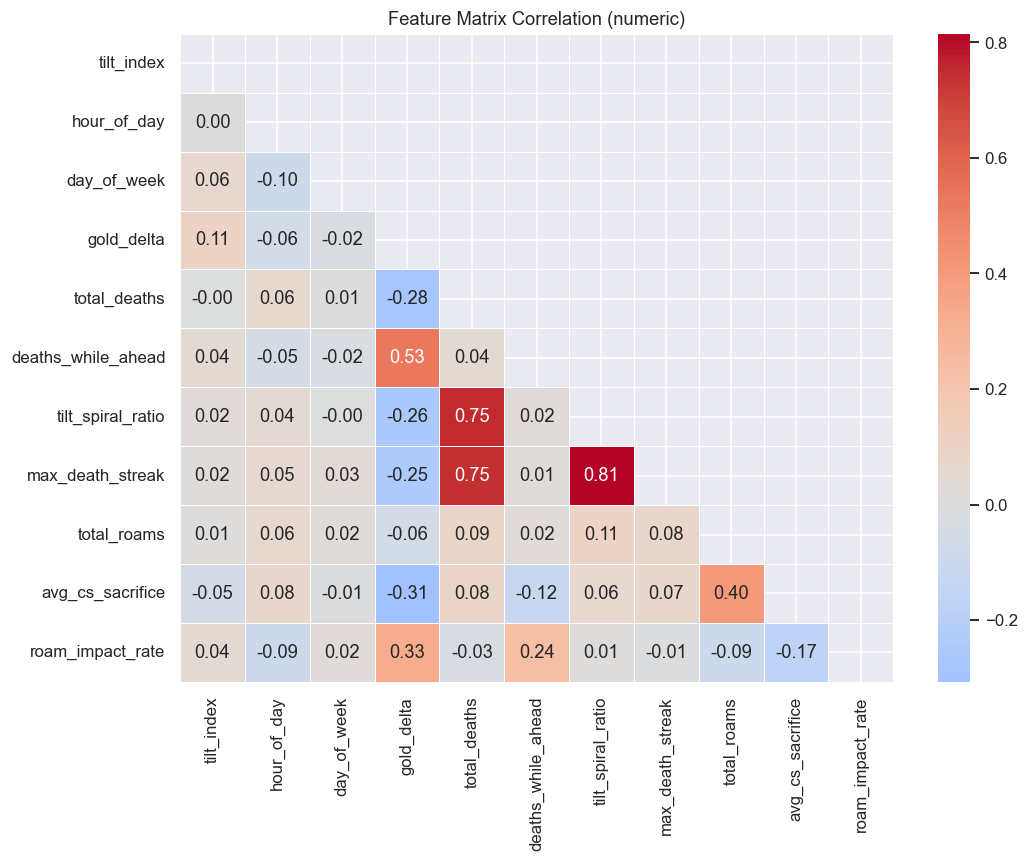

In [43]:
# Correlation heatmap — numeric features only
numeric_cols = fm.select_dtypes(include="number").columns.tolist()

fig, ax = plt.subplots(figsize=(10, 8))
corr = fm[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    ax=ax,
)
ax.set(title="Feature Matrix Correlation (numeric)")
plt.tight_layout()
plt.show()

In [44]:
conn.close()
print("Notebook complete — all cells executed cleanly.")

Notebook complete — all cells executed cleanly.
